<a href="https://colab.research.google.com/github/Navyasri-21/Server-Log-Anomaly-Detection/blob/main/Server_log_anololy_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("linux_auth_logs_multiple_anomalies.csv")

In [ ]:
print("Shape of Dataset:", df.shape)

df.head()

Shape of Dataset: (500000, 9)


,timestamp,source_ip,city,username,service,attempts,status,port,protocol
0,1992-08-08T23:59:11.713727,164.218.94.112,Berlin,nginx,sudo,1,Success,22,NaN
1,2024-01-09T23:45:07.484945,45.250.247.54,Berlin,nginx,cron,1,Success,22,TELNET
2,1998-03-04T19:23:04.009277,126.48.141.168,New York,ubuntu,cron,1,Failed,2222,TELNET
3,2004-07-08T14:46:58.281633,114.89.244.50,London,ec2-user,su,2,Failed,443,TELNET
4,1987-04-25T10:38:42.577672,186.144.249.195,New York,ec2-user,su,1,Success,2222,NaN


In [ ]:
# Column names
print(df.columns)

# Dataset information
df.info()

# First 5 rows
df.head()

Index(['timestamp', 'source_ip', 'city', 'username', 'service', 'attempts',
       'status', 'port', 'protocol'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   timestamp  500000 non-null  object
 1   source_ip  500000 non-null  object
 2   city       500000 non-null  object
 3   username   500000 non-null  object
 4   service    500000 non-null  object
 5   attempts   500000 non-null  int64 
 6   status     500000 non-null  object
 7   port       500000 non-null  int64 
 8   protocol   375253 non-null  object
dtypes: int64(2), object(7)
memory usage: 34.3+ MB


,timestamp,source_ip,city,username,service,attempts,status,port,protocol
0,1992-08-08T23:59:11.713727,164.218.94.112,Berlin,nginx,sudo,1,Success,22,NaN
1,2024-01-09T23:45:07.484945,45.250.247.54,Berlin,nginx,cron,1,Success,22,TELNET
2,1998-03-04T19:23:04.009277,126.48.141.168,New York,ubuntu,cron,1,Failed,2222,TELNET
3,2004-07-08T14:46:58.281633,114.89.244.50,London,ec2-user,su,2,Failed,443,TELNET
4,1987-04-25T10:38:42.577672,186.144.249.195,New York,ec2-user,su,1,Success,2222,NaN


In [ ]:
df.head()

,timestamp,source_ip,city,username,service,attempts,status,port,protocol
0,1992-08-08T23:59:11.713727,164.218.94.112,Berlin,nginx,sudo,1,Success,22,NaN
1,2024-01-09T23:45:07.484945,45.250.247.54,Berlin,nginx,cron,1,Success,22,TELNET
2,1998-03-04T19:23:04.009277,126.48.141.168,New York,ubuntu,cron,1,Failed,2222,TELNET
3,2004-07-08T14:46:58.281633,114.89.244.50,London,ec2-user,su,2,Failed,443,TELNET
4,1987-04-25T10:38:42.577672,186.144.249.195,New York,ec2-user,su,1,Success,2222,NaN


In [ ]:
print("Rows, Columns:", df.shape)

Rows, Columns: (500000, 9)


In [ ]:
print(df.columns.tolist())

['timestamp', 'source_ip', 'city', 'username', 'service', 'attempts', 'status', 'port', 'protocol']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   timestamp  500000 non-null  object
 1   source_ip  500000 non-null  object
 2   city       500000 non-null  object
 3   username   500000 non-null  object
 4   service    500000 non-null  object
 5   attempts   500000 non-null  int64 
 6   status     500000 non-null  object
 7   port       500000 non-null  int64 
 8   protocol   375253 non-null  object
dtypes: int64(2), object(7)
memory usage: 34.3+ MB


In [ ]:
df.head()

,timestamp,source_ip,city,username,service,attempts,status,port,protocol
0,1992-08-08T23:59:11.713727,164.218.94.112,Berlin,nginx,sudo,1,Success,22,NaN
1,2024-01-09T23:45:07.484945,45.250.247.54,Berlin,nginx,cron,1,Success,22,TELNET
2,1998-03-04T19:23:04.009277,126.48.141.168,New York,ubuntu,cron,1,Failed,2222,TELNET
3,2004-07-08T14:46:58.281633,114.89.244.50,London,ec2-user,su,2,Failed,443,TELNET
4,1987-04-25T10:38:42.577672,186.144.249.195,New York,ec2-user,su,1,Success,2222,NaN


In [ ]:
df.tail()

,timestamp,source_ip,city,username,service,attempts,status,port,protocol
499995,1999-10-10T17:11:03.208107,199.193.241.205,Singapore,root,cron,1,Success,443,RDP
499996,2023-09-27T16:28:27.694235,80.154.224.227,London,ubuntu,login,1,Failed,22,RDP
499997,1982-07-01T20:44:52.992557,28.175.164.105,Singapore,admin,sudo,3,Failed,80,RDP
499998,1975-02-04T13:16:39.732237,25.41.87.72,New York,ec2-user,ssh,1,Success,80,RDP
499999,1987-09-14T10:25:53.266296,152.19.154.46,London,www-data,ssh,1,Failed,58886,SSH2


In [ ]:
df.isnull().sum()

,0
timestamp,0
source_ip,0
city,0
username,0
service,0
attempts,0
status,0
port,0
protocol,124747


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df.describe()

,attempts,port
count,500000.000000,500000.000000
mean,1.976318,878.454860
std,3.794770,4263.302544
min,1.000000,22.000000
25%,1.000000,22.000000
50%,1.000000,80.000000
75%,2.000000,443.000000
max,50.000000,65525.000000


In [ ]:
df.describe(include='object')

,timestamp,source_ip,city,username,service,status,protocol
count,500000,500000,500000,500000,500000,500000,375253
unique,500000,499960,9,94714,5,2,3
top,2025-02-22T07:12:19.844536,13.237.233.25,Tokyo,root,sudo,Failed,SSH2
freq,1,2,99372,62697,104661,253588,125691


In [ ]:
categorical_cols = [
    'city',
    'username',
    'service',
    'status',
    'protocol'
]

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts().head(10))


 city
city
Tokyo        99372
New York     98973
Singapore    98511
Berlin       98481
London       98250
Tehran        1635
Caracas       1628
Pyongyang     1585
Moscow        1565
Name: count, dtype: int64

 username
username
root        62697
nginx       59874
www-data    59318
admin       57820
ec2-user    57698
ubuntu      57611
mysql        2030
zsmith         36
esmith         35
nsmith         35
Name: count, dtype: int64

 service
service
sudo     104661
login     98992
cron      98804
su        98784
ssh       98759
Name: count, dtype: int64

 status
status
Failed     253588
Success    246412
Name: count, dtype: int64

 protocol
protocol
SSH2      125691
TELNET    124784
RDP       124778
Name: count, dtype: int64


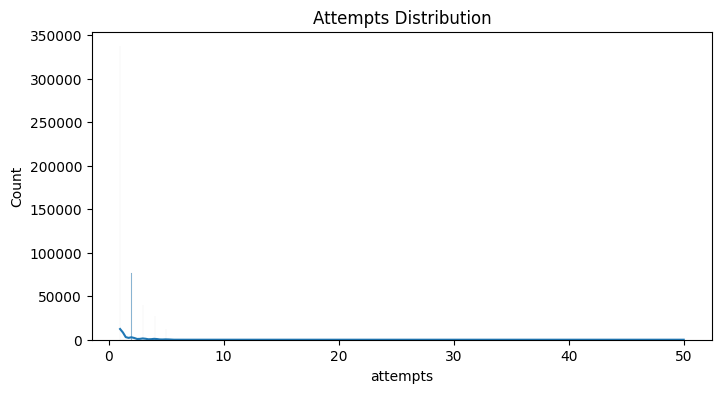

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['attempts'], kde=True)
plt.title("Attempts Distribution")
plt.show()

In [ ]:
df['attempts'].describe()

,attempts
count,500000.000000
mean,1.976318
std,3.794770
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,50.000000


In [ ]:
print(df['attempts'].value_counts().head(20))

attempts
1     337131
2      76568
3      40157
4      27779
5      12032
26       206
49       195
48       194
50       192
25       189
30       186
27       186
37       186
16       186
31       186
35       185
33       184
18       183
17       183
46       182
Name: count, dtype: int64


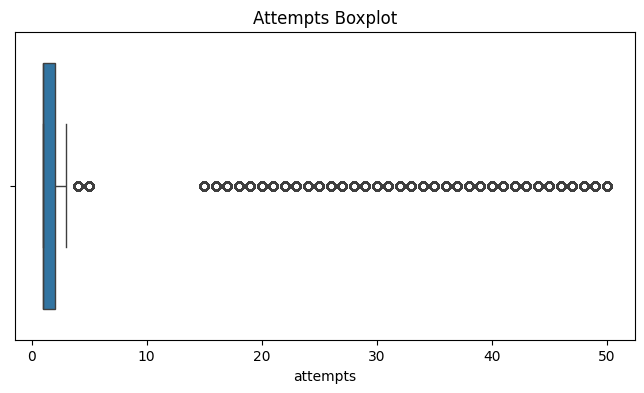

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['attempts'])
plt.title("Attempts Boxplot")
plt.show()

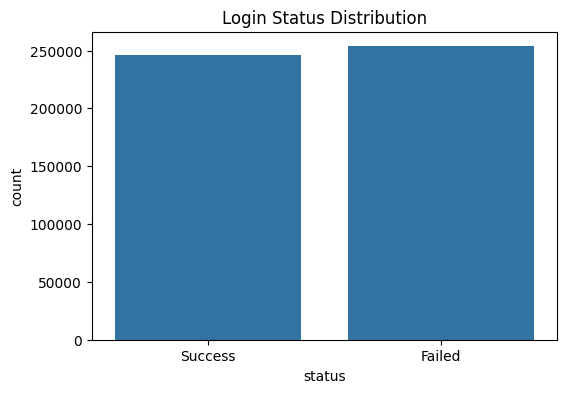

status
Failed     253588
Success    246412
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='status', data=df)
plt.title("Login Status Distribution")
plt.show()

print(df['status'].value_counts())

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')

In [ ]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek

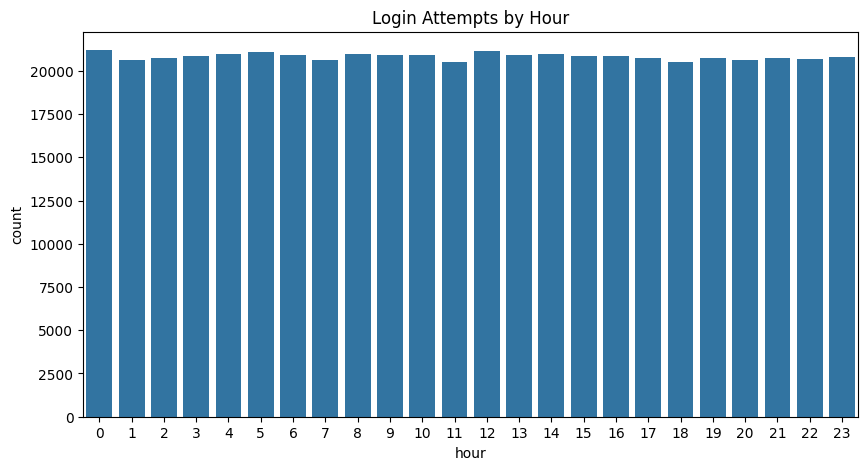

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='hour', data=df)
plt.title("Login Attempts by Hour")
plt.show()

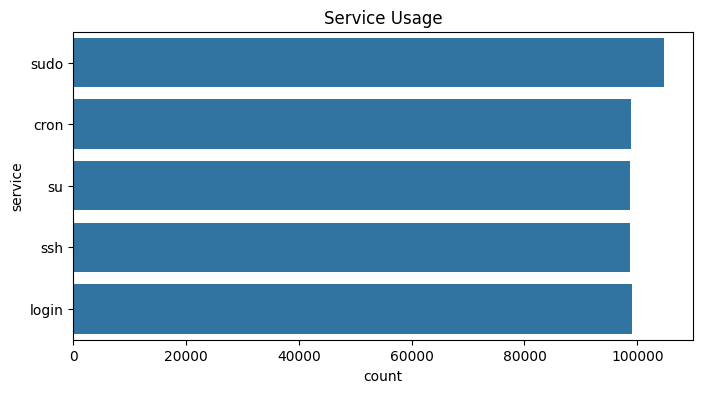

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(y='service', data=df)
plt.title("Service Usage")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

cols = [
    'source_ip',
    'city',
    'username',
    'service',
    'status',
    'protocol'
]

encoders = {}

for col in cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

NameError: name 'df' is not defined

In [ ]:
features = [
    'source_ip',
    'city',
    'username',
    'service',
    'attempts',
    'status',
    'port',
    'protocol',
    'hour',
    'day_of_week'
]

X = df[features]

In [ ]:
X.head()

,source_ip,city,username,service,attempts,status,port,protocol,hour,day_of_week
0,160968,0,63250,4,1,1,22,3,23,5
1,366521,0,63250,0,1,1,22,2,23,1
2,68783,4,86568,0,1,0,2222,2,19,2
3,40127,2,24426,3,2,0,443,2,14,3
4,214468,4,24426,3,1,1,2222,3,10,5


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

model.fit(X)

IsolationForest(contamination=0.05, random_state=42)

In [ ]:
df['anomaly'] = model.predict(X)

In [ ]:
df['anomaly'].value_counts()

,count
anomaly,
1,475000
-1,25000


In [ ]:
anomalies = df[df['anomaly'] == -1]

anomalies.head(10)

,timestamp,source_ip,city,username,service,attempts,status,port,protocol,hour,day,month,day_of_week,anomaly
37,1978-07-25 20:32:55.393293,143826,4,24426,1,1,0,36100,3,20,25,7,1,-1
75,1973-09-04 06:29:12.352307,447692,6,698,1,29,0,22,1,6,4,9,1,-1
89,1971-12-25 03:28:16.720176,23601,2,86568,0,1,0,41885,2,3,25,12,5,-1
106,2007-08-07 13:08:30.500412,24909,8,698,1,1,1,2222,3,13,7,8,1,-1
127,1989-06-02 16:54:59.342203,446963,0,92408,0,4,1,2222,2,16,2,6,4,-1
147,1994-02-06 01:14:12.620814,51037,2,24426,0,1,0,2222,2,1,6,2,6,-1
153,1975-03-03 00:25:33.336326,311251,6,86568,2,4,1,443,3,0,3,3,0,-1
174,1970-05-11 23:08:59.904707,414172,1,24426,3,3,1,2222,3,23,11,5,0,-1
203,1993-02-10 02:25:03.571830,308148,4,698,4,5,0,2222,0,2,10,2,2,-1
213,1983-01-15 19:38:12.654805,116849,4,24426,4,1,0,38618,2,19,15,1,5,-1


anomaly
 1    475000
-1     25000
Name: count, dtype: int64


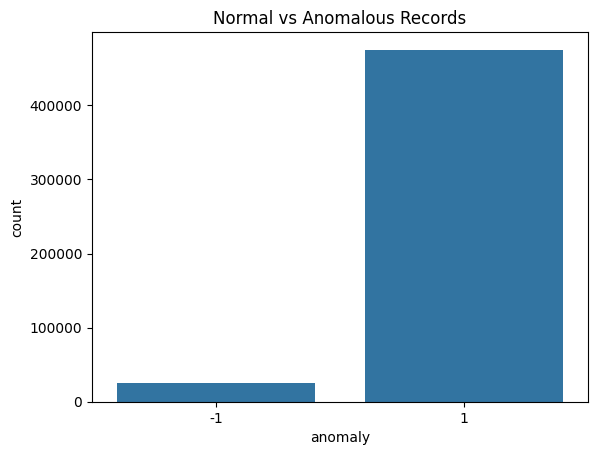

In [ ]:
print(df['anomaly'].value_counts())
sns.countplot(x='anomaly', data=df)
plt.title("Normal vs Anomalous Records")
plt.show()

In [ ]:
anomalies = df[df['anomaly'] == -1]

print("Number of anomalies:", len(anomalies))
anomalies.head()

Number of anomalies: 25000


,timestamp,source_ip,city,username,service,attempts,status,port,protocol,hour,day,month,day_of_week,anomaly
37,1978-07-25 20:32:55.393293,143826,4,24426,1,1,0,36100,3,20,25,7,1,-1
75,1973-09-04 06:29:12.352307,447692,6,698,1,29,0,22,1,6,4,9,1,-1
89,1971-12-25 03:28:16.720176,23601,2,86568,0,1,0,41885,2,3,25,12,5,-1
106,2007-08-07 13:08:30.500412,24909,8,698,1,1,1,2222,3,13,7,8,1,-1
127,1989-06-02 16:54:59.342203,446963,0,92408,0,4,1,2222,2,16,2,6,4,-1


In [ ]:
anomalies['username'].value_counts().head(10)

,count
username,
698,6156
74152,5928
24426,2647
92408,2357
86568,1716
63250,1410
62301,18
6168,6
5833,5


In [ ]:
anomalies['source_ip'].value_counts().head(10)

,count
source_ip,
131384,1
143826,1
447692,1
23601,1
24909,1
446963,1
51037,1
311251,1
33914,1


In [ ]:
anomalies.groupby('status').size()

,0
status,
0,19271
1,5729


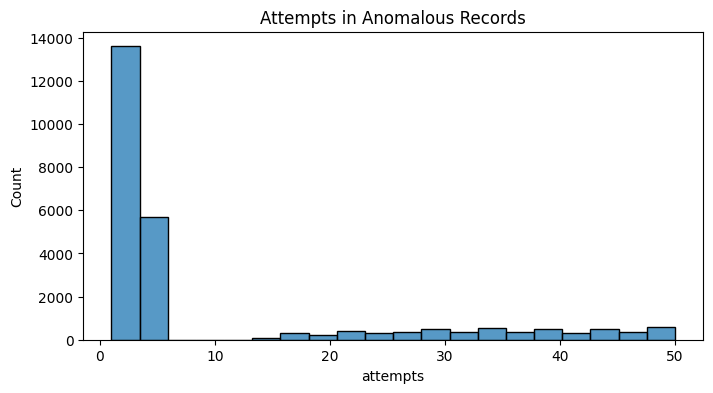

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(anomalies['attempts'], bins=20)#This histogram visualizes the distribution of attempts among records identified as anomalies by the Isolation Forest model.
plt.title("Attempts in Anomalous Records")
plt.show()

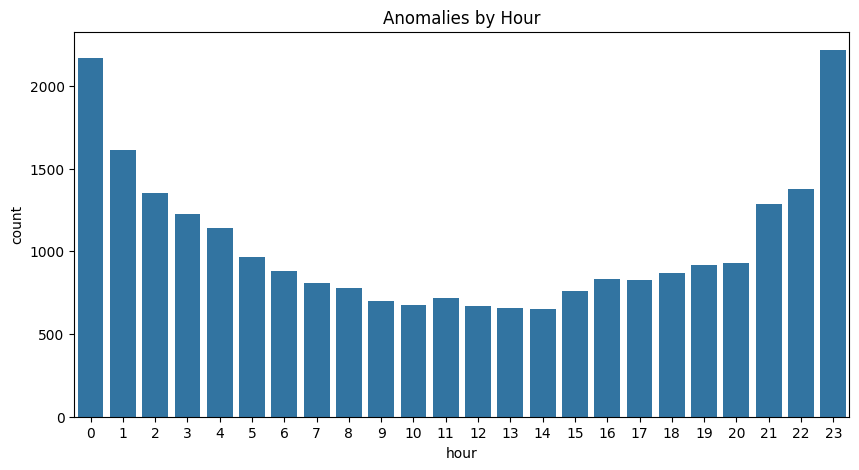

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='hour', data=anomalies)
plt.title("Anomalies by Hour")
plt.show()

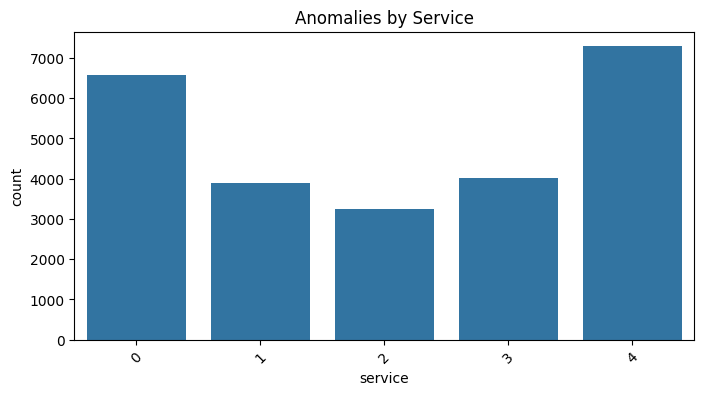

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='service', data=anomalies)
plt.title("Anomalies by Service")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import joblib

joblib.dump(model, "server_log_anomaly_model.pkl")

['server_log_anomaly_model.pkl']

In [ ]:
df.to_csv("server_log_results.csv", index=False)

In [ ]:
print("Total Records:", len(df))
print("Total Anomalies:", len(anomalies))
print("Anomaly Percentage:", round(len(anomalies)/len(df)*100,2), "%")

Total Records: 500000
Total Anomalies: 25000
Anomaly Percentage: 5.0 %


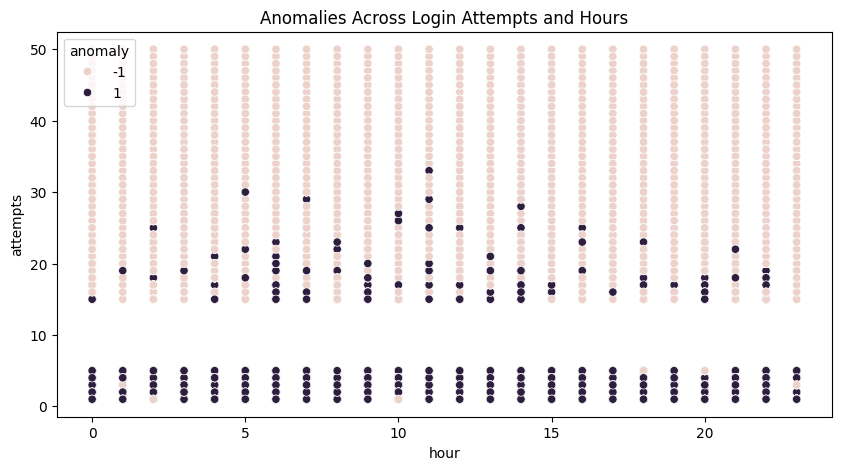

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x=df['hour'],
    y=df['attempts'],
    hue=df['anomaly']
)

plt.title("Anomalies Across Login Attempts and Hours")
plt.show()

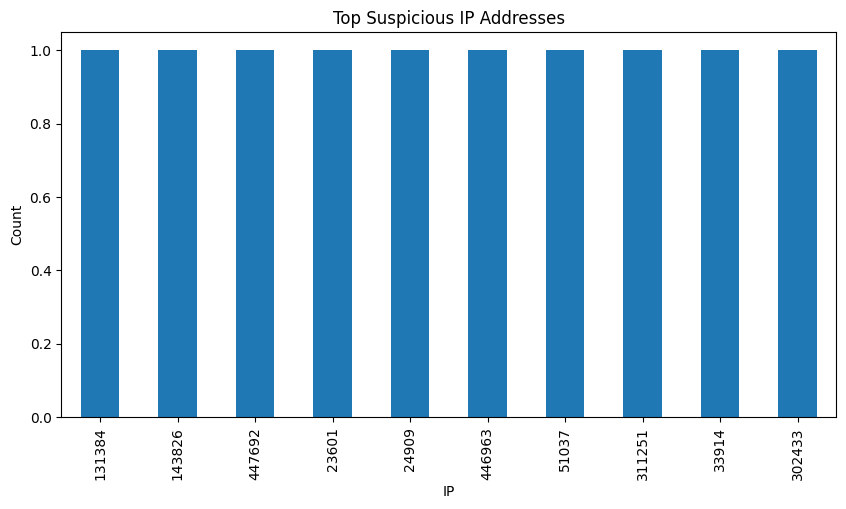

In [ ]:
top_ips = anomalies['source_ip'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_ips.plot(kind='bar')

plt.title("Top Suspicious IP Addresses")
plt.xlabel("IP")
plt.ylabel("Count")
plt.show()

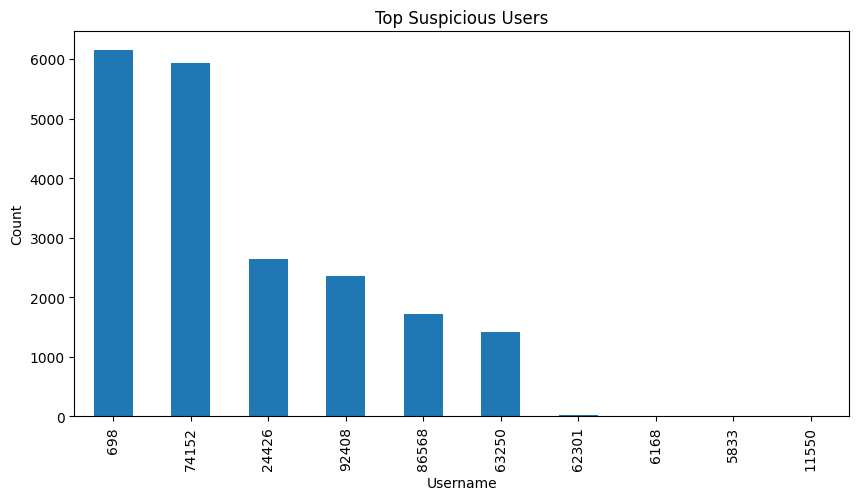

In [ ]:
top_users = anomalies['username'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_users.plot(kind='bar')

plt.title("Top Suspicious Users")
plt.xlabel("Username")
plt.ylabel("Count")
plt.show()

In [ ]:
summary = {
    "Total Records": len(df),
    "Normal Records": len(df[df['anomaly']==1]),
    "Anomalous Records": len(df[df['anomaly']==-1]),
    "Anomaly Percentage": round(
        len(df[df['anomaly']==-1]) / len(df) * 100, 2
    )
}

print(summary)

{'Total Records': 500000, 'Normal Records': 475000, 'Anomalous Records': 25000, 'Anomaly Percentage': 5.0}


In [ ]:
def detect_log_anomaly(data):
    prediction = model.predict(data)

    if prediction[0] == -1:
        return "Anomaly Detected"

    return "Normal Activity"

In [ ]:
sample = X.iloc[[0]]

print(detect_log_anomaly(sample))

Normal Activity


In [ ]:
anomaly_sample = df[df['anomaly'] == -1]

sample = anomaly_sample[features].iloc[[0]]

print(detect_log_anomaly(sample))

Anomaly Detected
